In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


Silakan ganti path di bawah (`/content/drive/MyDrive/tips.csv`) jika file Anda berada di lokasi yang berbeda di Google Drive.

In [3]:
df = pd.read_csv('/content/drive/MyDrive/tips.csv')
df

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4
...,...,...,...,...,...,...,...
239,29.03,5.92,Male,No,Sat,Dinner,3
240,27.18,2.00,Female,Yes,Sat,Dinner,2
241,22.67,2.00,Male,Yes,Sat,Dinner,2
242,17.82,1.75,Male,No,Sat,Dinner,2


In [ ]:
# Opsi lain membaca data dari Colabs file (namun kekurangannya data perlu diinput setiap saat)

df = pd.read_csv('/content/tips.csv')

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 244 entries, 0 to 243
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   total_bill  244 non-null    float64
 1   tip         244 non-null    float64
 2   sex         244 non-null    object 
 3   smoker      244 non-null    object 
 4   day         244 non-null    object 
 5   time        244 non-null    object 
 6   size        244 non-null    int64  
dtypes: float64(2), int64(1), object(4)
memory usage: 13.5+ KB


In [ ]:
df.shape

(244, 7)

In [ ]:
df.drop(['size'], axis=1,inplace= True) #menghapus kolom size pada dataset

df

,total_bill,tip,sex,smoker,day,time
0,16.99,1.01,Female,No,Sun,Dinner
1,10.34,1.66,Male,No,Sun,Dinner
2,21.01,3.50,Male,No,Sun,Dinner
3,23.68,3.31,Male,No,Sun,Dinner
4,24.59,3.61,Female,No,Sun,Dinner
...,...,...,...,...,...,...
239,29.03,5.92,Male,No,Sat,Dinner
240,27.18,2.00,Female,Yes,Sat,Dinner
241,22.67,2.00,Male,Yes,Sat,Dinner
242,17.82,1.75,Male,No,Sat,Dinner


In [ ]:
df.isnull().sum() #melihat missing value

#nilai 0 menandakan tidak ada missing value

,0
total_bill,0
tip,0
sex,0
smoker,0
day,0
time,0


In [ ]:
df["sex"].value_counts()

,count
sex,
Male,157
Female,87


In [ ]:
df["smoker"].value_counts()

,count
smoker,
No,151
Yes,93


In [ ]:
df["sex"].value_counts() / len(df) * 100

,count
sex,
Male,64.344262
Female,35.655738


In [ ]:
df.describe() # analisa statistik deskriptif

,total_bill,tip
count,244.000000,244.000000
mean,19.785943,2.998279
std,8.902412,1.383638
min,3.070000,1.000000
25%,13.347500,2.000000
50%,17.795000,2.900000
75%,24.127500,3.562500
max,50.810000,10.000000


Scatterplot

<Axes: xlabel='total_bill', ylabel='tip'>

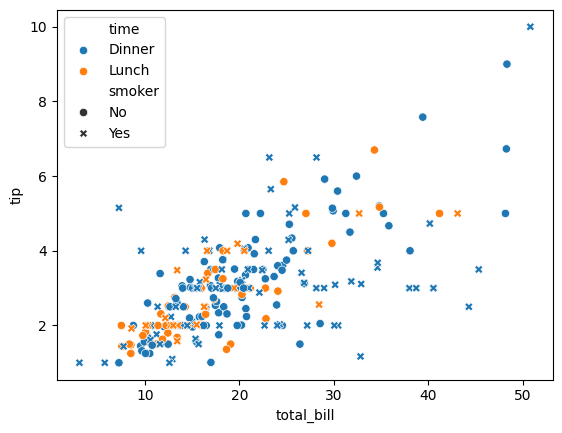

In [ ]:
sns.scatterplot(data = df,
                x = "total_bill",
                y = "tip",
                hue = "time",
                style = "smoker")

Berdasarkan scatterplot:
1. ada kemungkinan hubungan antara total bill dengan tips yang diberikan, semakin tinggi total bil /pengeluaran maka tips cendering lebih besar
2. jumlah costumer yang memesan makanan di malam hari lebih besar daripada di siang hari
3. jumlah costumer yang tidak merokok lebih banyak daripada yang merokok

In [ ]:
df["day"].value_counts()

,count
day,
Sat,87
Sun,76
Thur,62
Fri,19


Another chart (bar and violin chart)

In [ ]:
import plotly.express as px

long_df = px.data.tips()

fig = px.bar(long_df, x="day", y="tip", color="time", title="tip /day")
fig.show()

Berdasarkan barchart:
1. Jumlah tips paling banyak diberikan di hari Sabtu dan minggu ketika makan malam
2. Tips yang diberikan pada saat makan siang di hari Kamis lebih banyak daripada makan siang di hari lain
3. Tips paling sedikit terdapat pada hari jumat

[Text(0.5, 0, 'Hari Operational'),
 Text(0, 0.5, 'Total Harga'),
 Text(0.5, 1.0, 'Penjualan di Restoran')]

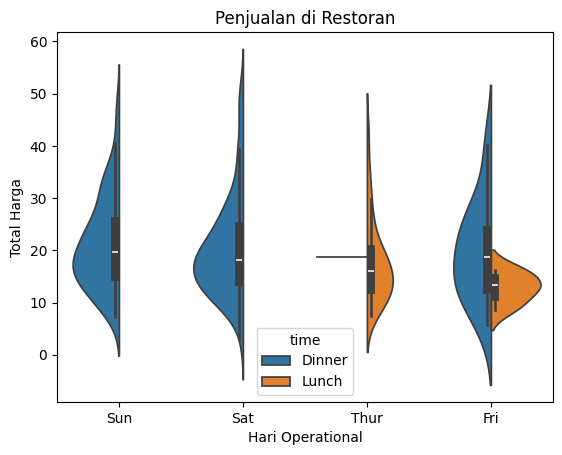

In [ ]:
ax = sns.violinplot(x = "day",
               y = "total_bill",
               hue = "time",
               split = True,
               data = df)

ax.set(xlabel = "Hari Operational",
       ylabel = "Total Harga",
       title = "Penjualan di Restoran")

Berdasarkan grafik:
1. Costumer melakukan transaksi dengan total harga rata-rata sekitar 10-20
2. Transaksi paling banyak di hari Sabtu dan Minggu
3. Pada hari Sabtu terdapat transaksi tertinggi (mencapai total harga 60)

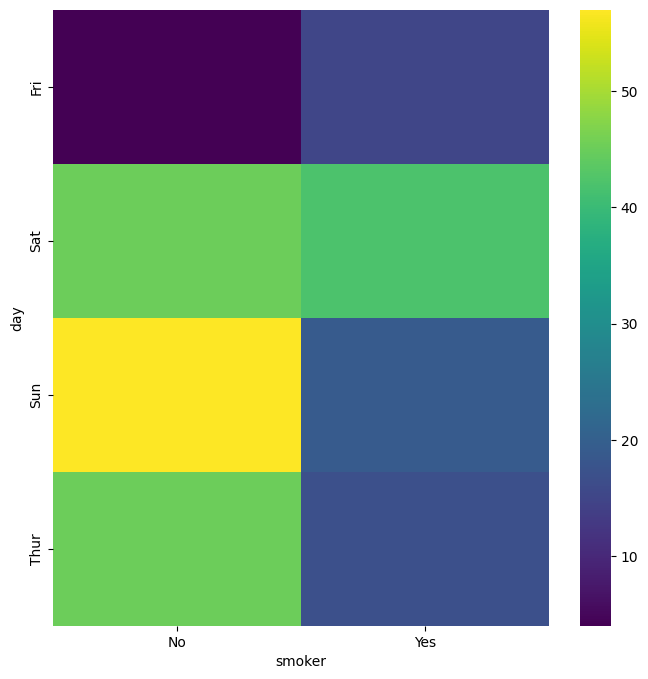

In [ ]:
plt.subplots(figsize=(8, 8))
df_2dhist = pd.DataFrame({
    x_label: grp['day'].value_counts()
    for x_label, grp in df.groupby('smoker')
})
sns.heatmap(df_2dhist, cmap='viridis')
plt.xlabel('smoker')
_ = plt.ylabel('day')

Berdasarkan gambar:
1. Pada hari Minggu lebih banyak costumer yang bukan perokok di bandingkan hari lain dan pada hari Jumat costumer yang tidak merokok jauh lebih kecil dari hari lain.
2. Pada hari Sabtu lebih banyak costumer yang merokok di bandingkan hari lain